# Archivist RAG Hyperparameter Optimization

This notebook implements **Track 1 only**: a controlled comparison of RAG chunk size,
chunk overlap, and retrieval depth. It uses the same source, questions, models,
temperature, prompt rubric, and manual scoring rubric for every configuration.

Quality scores are never inferred from model output. Raw system measurements are
automatic; correctness, groundedness, retrieval hit, and hallucination handling are
entered by a human reviewer.

## 1. Baseline Results Recap

The original, manually scored 15-question baseline reported:

- No-RAG correctness: 63.3%
- RAG correctness: 93.3%
- Fully correct without RAG: 46.7%
- Fully correct with RAG: 86.7%
- Retrieval Hit Rate@3: 100%
- Average groundedness: 0.93

These values came from a small, manually scored 15-question baseline. They describe
the earlier no-RAG/RAG comparison; the `baseline` configuration below is rerun so
all optimization comparisons use the same runner and timing instrumentation.

## 2. Optimization Objective

Evaluate focused RAG configurations while holding all non-tuned variables constant.

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from datetime import datetime, timezone
import hashlib
import json
import platform
import sys
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import ollama
import pandas as pd
from IPython.display import display
from sklearn.metrics.pairwise import cosine_similarity

SOURCE_PATH = Path("data/openstax_section_1_3.txt")
QUESTIONS_PATH = Path("data/openstax_questions.csv")
RESULTS_DIR = Path("results")
CACHE_DIR = RESULTS_DIR / "embedding_cache"
CHARTS_DIR = RESULTS_DIR / "charts"
RAW_RESULTS_PATH = RESULTS_DIR / "optimization_raw_results.csv"
MANUAL_REVIEW_PATH = RESULTS_DIR / "optimization_manual_review.csv"
SUMMARY_PATH = RESULTS_DIR / "optimization_summary.csv"
METADATA_PATH = RESULTS_DIR / "optimization_metadata.json"
REPORT_PATH = RESULTS_DIR / "optimization_report_summary.txt"

CHAT_MODEL = "qwen3:0.6b"
EMBEDDING_MODEL = "nomic-embed-text:latest"
OLLAMA_HOST = "http://localhost:11434"
TEMPERATURE = 0.0
NOTEBOOK_VERSION = "1.0.0"
RUN_EXPERIMENTS = True
FORCE_RERUN = False

for directory in (RESULTS_DIR, CACHE_DIR, CHARTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
client = ollama.Client(host=OLLAMA_HOST)

## 3. Experiment Configurations

In [2]:
EXPERIMENTS: list[dict[str, Any]] = [
    {"experiment_id": "baseline", "chunk_size": 1000, "chunk_overlap": 200, "top_k": 3, "prompt_version": "strict"},
    {"experiment_id": "smaller_chunks", "chunk_size": 600, "chunk_overlap": 100, "top_k": 3, "prompt_version": "strict"},
    {"experiment_id": "medium_chunks", "chunk_size": 800, "chunk_overlap": 150, "top_k": 3, "prompt_version": "strict"},
    {"experiment_id": "larger_chunks", "chunk_size": 1400, "chunk_overlap": 250, "top_k": 3, "prompt_version": "strict"},
    {"experiment_id": "top_k_1", "chunk_size": 1000, "chunk_overlap": 200, "top_k": 1, "prompt_version": "strict"},
    {"experiment_id": "top_k_5", "chunk_size": 1000, "chunk_overlap": 200, "top_k": 5, "prompt_version": "strict"},
]

@dataclass
class ExperimentResult:
    """One question/configuration result with automatic and manual fields."""
    experiment_id: str
    question_id: int
    question: str
    expected_answerable: bool
    chunk_size: int
    chunk_overlap: int
    top_k: int
    prompt_version: str
    rag_answer: str
    retrieved_chunk_ids: str
    retrieved_similarities: str
    highest_similarity: float
    mean_similarity: float
    lowest_similarity: float
    retrieval_seconds: float
    generation_seconds: float
    total_seconds: float
    retrieved_character_count: int
    answer_character_count: int
    correctness: float | None = None
    groundedness: float | None = None
    retrieval_hit: float | None = None
    hallucination_handling: float | None = None
    review_notes: str = ""

## 4. Automated Experiment Runner

In [3]:
def clean_text(text: str) -> str:
    """Normalize source whitespace without discarding paragraph boundaries."""
    paragraphs = [" ".join(p.split()) for p in text.replace("\r\n", "\n").split("\n\n")]
    cleaned = "\n\n".join(p for p in paragraphs if p)
    if not cleaned:
        raise ValueError("Source document is empty after cleaning.")
    return cleaned

def load_questions(path: Path) -> pd.DataFrame:
    """Load and validate the fixed evaluation set."""
    frame = pd.read_csv(path)
    required = {"question_id", "question", "expected_answerable"}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"Question CSV is missing columns: {sorted(missing)}")
    frame["expected_answerable"] = (
        frame["expected_answerable"].astype(str).str.lower().map({"true": True, "false": False})
    )
    if frame["expected_answerable"].isna().any() or frame["question_id"].duplicated().any():
        raise ValueError("Questions need unique IDs and true/false expected_answerable values.")
    return frame

def chunk_text(text: str, chunk_size: int, overlap: int) -> list[dict[str, Any]]:
    """Split text into stable overlapping character chunks."""
    if chunk_size <= 0 or overlap < 0 or overlap >= chunk_size:
        raise ValueError("Require chunk_size > 0 and 0 <= overlap < chunk_size.")
    chunks, start, index = [], 0, 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        if end < len(text):
            boundary = max(text.rfind("\n\n", start, end), text.rfind(". ", start, end))
            if boundary > start + chunk_size // 2:
                end = boundary + (2 if text[boundary:boundary + 2] == ". " else 0)
        chunk = text[start:end].strip()
        if chunk:
            chunks.append({"chunk_id": f"chunk_{index:04d}", "text": chunk, "start": start, "end": end})
            index += 1
        if end >= len(text):
            break
        next_start = end - overlap
        start = next_start if next_start > start else end
    return chunks

def source_hash(text: str) -> str:
    """Return the SHA-256 digest of the cleaned source."""
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

def embedding_cache_path(document_hash: str, chunk_size: int, overlap: int) -> Path:
    """Build a stable cache path from source and embedding settings."""
    safe_model = EMBEDDING_MODEL.replace("/", "_").replace(":", "-")
    key = f"sha256_{document_hash}_chunk{chunk_size}_overlap{overlap}_{safe_model}"
    return CACHE_DIR / f"{key}.npz"

def embed_text(text: str) -> np.ndarray:
    """Embed one non-empty string with the configured local Ollama model."""
    response = client.embeddings(model=EMBEDDING_MODEL, prompt=text)
    vector = response["embedding"] if isinstance(response, dict) else response.embedding
    result = np.asarray(vector, dtype=float)
    if result.ndim != 1 or not result.size or not np.isfinite(result).all():
        raise ValueError("Ollama returned an invalid embedding.")
    return result

def load_or_create_embeddings(
    chunks: list[dict[str, Any]], document_hash: str, chunk_size: int, overlap: int
) -> np.ndarray:
    """Load a compatible embedding cache or create and atomically replace it."""
    path = embedding_cache_path(document_hash, chunk_size, overlap)
    if path.exists():
        with np.load(path, allow_pickle=False) as cached:
            embeddings = cached["embeddings"]
            count = int(cached["count"])
            dimension = int(cached["dimension"])
        if count == len(chunks) and embeddings.shape == (count, dimension) and dimension > 0:
            return embeddings
        print(f"Ignoring incompatible embedding cache: {path}")
    embeddings = np.vstack([embed_text(chunk["text"]) for chunk in chunks])
    if embeddings.shape[0] != len(chunks) or embeddings.shape[1] == 0:
        raise ValueError("Embedding count or dimension validation failed.")
    temporary = path.with_suffix(".tmp.npz")
    np.savez_compressed(temporary, embeddings=embeddings, count=len(chunks), dimension=embeddings.shape[1])
    temporary.replace(path)
    return embeddings

def retrieve_chunks(
    question: str, chunks: list[dict[str, Any]], chunk_embeddings: np.ndarray, top_k: int
) -> list[dict[str, Any]]:
    """Retrieve the most similar chunks and attach cosine similarities."""
    if len(chunks) != len(chunk_embeddings):
        raise ValueError("Chunk and embedding counts differ.")
    query = embed_text(question).reshape(1, -1)
    if query.shape[1] != chunk_embeddings.shape[1]:
        raise ValueError("Query and chunk embedding dimensions differ.")
    scores = cosine_similarity(query, chunk_embeddings)[0]
    indices = np.argsort(scores)[::-1][:min(top_k, len(chunks))]
    return [{**chunks[i], "similarity": float(scores[i])} for i in indices]

def build_prompt(question: str, retrieved: list[dict[str, Any]], prompt_version: str) -> str:
    """Build a source-constrained prompt with inspectable chunk citations."""
    if prompt_version != "strict":
        raise ValueError(f"Unknown prompt_version: {prompt_version}")
    context = "\n\n".join(f"[{c['chunk_id']}]\n{c['text']}" for c in retrieved)
    return (
        "You are Archivist, an educational assistant. Answer only from the course "
        "context below. Cite supporting chunk IDs in square brackets. If the context "
        "does not contain the answer, say so explicitly; do not use outside knowledge.\n\n"
        f"COURSE CONTEXT\n{context}\n\nQUESTION\n{question}\n\nANSWER"
    )

def generate_answer(prompt: str) -> str:
    """Generate a deterministic answer using the fixed local chat model."""
    response = client.chat(
        model=CHAT_MODEL,
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": TEMPERATURE},
    )
    answer = response["message"]["content"] if isinstance(response, dict) else response.message.content
    return str(answer).strip()

def run_question_experiment(
    experiment: dict, question_row: dict, chunks: list[dict], chunk_embeddings: np.ndarray
) -> ExperimentResult:
    """Retrieve, prompt, generate, and time one question/configuration pair."""
    total_start = time.perf_counter()
    retrieval_start = time.perf_counter()
    retrieved = retrieve_chunks(question_row["question"], chunks, chunk_embeddings, experiment["top_k"])
    retrieval_seconds = time.perf_counter() - retrieval_start
    prompt = build_prompt(question_row["question"], retrieved, experiment["prompt_version"])
    generation_start = time.perf_counter()
    answer = generate_answer(prompt)
    generation_seconds = time.perf_counter() - generation_start
    similarities = [item["similarity"] for item in retrieved]
    return ExperimentResult(
        experiment_id=experiment["experiment_id"], question_id=int(question_row["question_id"]),
        question=question_row["question"], expected_answerable=bool(question_row["expected_answerable"]),
        chunk_size=experiment["chunk_size"], chunk_overlap=experiment["chunk_overlap"],
        top_k=experiment["top_k"], prompt_version=experiment["prompt_version"], rag_answer=answer,
        retrieved_chunk_ids=json.dumps([item["chunk_id"] for item in retrieved]),
        retrieved_similarities=json.dumps([round(value, 8) for value in similarities]),
        highest_similarity=max(similarities), mean_similarity=float(np.mean(similarities)),
        lowest_similarity=min(similarities), retrieval_seconds=retrieval_seconds,
        generation_seconds=generation_seconds, total_seconds=time.perf_counter() - total_start,
        retrieved_character_count=sum(len(item["text"]) for item in retrieved),
        answer_character_count=len(answer),
    )

def _write_csv_safely(frame: pd.DataFrame, path: Path) -> None:
    """Replace a CSV through a sibling temporary file."""
    temporary = path.with_suffix(".tmp")
    frame.to_csv(temporary, index=False)
    temporary.replace(path)

def run_all_experiments(
    experiments: list[dict], questions_df: pd.DataFrame, clean_document: str
) -> pd.DataFrame:
    """Run all missing pairs, checkpoint after each question, and support resume."""
    results = pd.read_csv(RAW_RESULTS_PATH) if RAW_RESULTS_PATH.exists() else pd.DataFrame()
    if FORCE_RERUN:
        results = pd.DataFrame()
    completed = (
        set(zip(results["experiment_id"].astype(str), results["question_id"].astype(int)))
        if not results.empty else set()
    )
    document_hash = source_hash(clean_document)
    total = len(experiments) * len(questions_df)
    done = len(completed)
    for experiment in experiments:
        chunks = chunk_text(clean_document, experiment["chunk_size"], experiment["chunk_overlap"])
        embeddings = load_or_create_embeddings(
            chunks, document_hash, experiment["chunk_size"], experiment["chunk_overlap"]
        )
        for row in questions_df.to_dict("records"):
            pair = (experiment["experiment_id"], int(row["question_id"]))
            if pair in completed:
                print(f"[{done}/{total}] skip {pair[0]} question {pair[1]}")
                continue
            result = pd.DataFrame([asdict(run_question_experiment(experiment, row, chunks, embeddings))])
            results = pd.concat([results, result], ignore_index=True)
            results = results.drop_duplicates(["experiment_id", "question_id"], keep="last")
            _write_csv_safely(results, RAW_RESULTS_PATH)
            completed.add(pair)
            done += 1
            print(f"[{done}/{total}] saved {pair[0]} question {pair[1]}")
    return results.sort_values(["experiment_id", "question_id"]).reset_index(drop=True)

In [4]:
questions_df = load_questions(QUESTIONS_PATH)
clean_document = clean_text(SOURCE_PATH.read_text(encoding="utf-8"))
if RUN_EXPERIMENTS:
    raw_results_df = run_all_experiments(EXPERIMENTS, questions_df, clean_document)
else:
    raw_results_df = pd.read_csv(RAW_RESULTS_PATH) if RAW_RESULTS_PATH.exists() else pd.DataFrame()
    print("Generation is disabled. Start Ollama, set RUN_EXPERIMENTS = True, and rerun this cell.")

[90/90] skip baseline question 1
[90/90] skip baseline question 2
[90/90] skip baseline question 3
[90/90] skip baseline question 4
[90/90] skip baseline question 5
[90/90] skip baseline question 6
[90/90] skip baseline question 7
[90/90] skip baseline question 8
[90/90] skip baseline question 9
[90/90] skip baseline question 10
[90/90] skip baseline question 11
[90/90] skip baseline question 12
[90/90] skip baseline question 13
[90/90] skip baseline question 14
[90/90] skip baseline question 15
[90/90] skip smaller_chunks question 1
[90/90] skip smaller_chunks question 2
[90/90] skip smaller_chunks question 3
[90/90] skip smaller_chunks question 4
[90/90] skip smaller_chunks question 5
[90/90] skip smaller_chunks question 6
[90/90] skip smaller_chunks question 7
[90/90] skip smaller_chunks question 8
[90/90] skip smaller_chunks question 9
[90/90] skip smaller_chunks question 10
[90/90] skip smaller_chunks question 11
[90/90] skip smaller_chunks question 12
[90/90] skip smaller_chunks 

## 5. Manual Scoring Export

After generation, score `results/optimization_manual_review.csv` in Jupyter, Excel,
Numbers, or another spreadsheet tool. Do not change the identifying columns.

- **Correctness:** 2 fully correct; 1 partially correct; 0 incorrect/unsupported.
- **Groundedness:** 1 fully supported; 0.5 partially supported; 0 unsupported.
- **Retrieval hit:** 1 if a retrieved chunk contains the needed information; otherwise 0.
- **Hallucination handling:** for unanswerable questions only, 1 if the answer correctly
  says the source lacks the answer; 0 if it invents or gives unsupported information.

In [5]:
MANUAL_COLUMNS = [
    "experiment_id", "question_id", "question", "expected_answerable", "rag_answer",
    "retrieved_chunk_ids", "retrieved_similarities", "correctness", "groundedness",
    "retrieval_hit", "hallucination_handling", "review_notes",
]

def export_manual_review(raw: pd.DataFrame) -> pd.DataFrame:
    """Create or update the review file without overwriting existing human scores."""
    if raw.empty:
        review = pd.DataFrame(columns=MANUAL_COLUMNS)
    else:
        base = raw.copy()
        for column in ("correctness", "groundedness", "retrieval_hit", "hallucination_handling"):
            base[column] = np.nan
        base["review_notes"] = ""
        review = base[MANUAL_COLUMNS]
        if MANUAL_REVIEW_PATH.exists():
            existing = pd.read_csv(MANUAL_REVIEW_PATH)
            score_columns = ["correctness", "groundedness", "retrieval_hit", "hallucination_handling", "review_notes"]
            available = [c for c in score_columns if c in existing.columns]
            if available:
                review = review.merge(
                    existing[["experiment_id", "question_id", *available]],
                    on=["experiment_id", "question_id"], how="left", suffixes=("", "_old")
                )
                for column in available:
                    review[column] = review[f"{column}_old"].combine_first(review[column])
                    review.drop(columns=f"{column}_old", inplace=True)
    _write_csv_safely(review, MANUAL_REVIEW_PATH)
    return review

manual_review_df = export_manual_review(raw_results_df)
print(f"Manual review rows: {len(manual_review_df)}; path: {MANUAL_REVIEW_PATH}")

Manual review rows: 90; path: results/optimization_manual_review.csv


## 6. Manual Score Validation

In [6]:
def _boolean_values(series: pd.Series) -> pd.Series:
    """Normalize persisted booleans and reject unknown values."""
    mapped = series.astype(str).str.strip().str.lower().map({"true": True, "false": False})
    if mapped.isna().any():
        raise ValueError("expected_answerable must contain only true/false values.")
    return mapped

def validate_manual_scores(scores: pd.DataFrame) -> None:
    """Raise one clear error containing all missing and invalid manual scores."""
    allowed_values = {
        "correctness": {0, 1, 2}, "groundedness": {0, 0.5, 1},
        "retrieval_hit": {0, 1}, "hallucination_handling": {0, 1},
    }
    required = {"experiment_id", "question_id", "expected_answerable", *allowed_values}
    missing_columns = required - set(scores.columns)
    if missing_columns:
        raise ValueError(f"Manual review is missing columns: {sorted(missing_columns)}")
    if scores.empty:
        raise ValueError("Manual review has no generated experiment rows yet.")
    answerable = _boolean_values(scores["expected_answerable"])
    errors = []
    required_masks = {
        "correctness": pd.Series(True, index=scores.index),
        "groundedness": pd.Series(True, index=scores.index),
        "retrieval_hit": answerable,
        "hallucination_handling": ~answerable,
    }
    for column, allowed in allowed_values.items():
        numeric = pd.to_numeric(scores[column], errors="coerce")
        missing = required_masks[column] & numeric.isna()
        invalid = numeric.notna() & ~numeric.isin(allowed)
        if missing.any():
            pairs = scores.loc[missing, ["experiment_id", "question_id"]].to_dict("records")
            errors.append(f"{column}: missing for {pairs}")
        if invalid.any():
            values = scores.loc[invalid, ["experiment_id", "question_id", column]].to_dict("records")
            errors.append(f"{column}: invalid values {values}; allowed={sorted(allowed)}")
    if errors:
        raise ValueError("Manual score validation failed:\n- " + "\n- ".join(errors))

scores_ready = False
try:
    validate_manual_scores(manual_review_df)
    scores_ready = True
    print("Manual scores are complete and valid.")
except ValueError as exc:
    print(exc)
    print("Summary metrics, rankings, charts, and claims remain disabled.")

Manual scores are complete and valid.


## 7. Summary Metrics

In [7]:
def summarize_experiments(results: pd.DataFrame) -> pd.DataFrame:
    """Calculate manual quality metrics and automatic descriptive statistics."""
    validate_manual_scores(results)
    frame = results.copy()
    frame["expected_answerable"] = _boolean_values(frame["expected_answerable"])
    for column in ("correctness", "groundedness", "retrieval_hit", "hallucination_handling"):
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    rows = []
    for experiment_id, group in frame.groupby("experiment_id", sort=False):
        answerable, unanswerable = group[group.expected_answerable], group[~group.expected_answerable]
        row = {
            "experiment_id": experiment_id, "question_count": len(group),
            "chunk_size": int(group.chunk_size.iloc[0]), "chunk_overlap": int(group.chunk_overlap.iloc[0]),
            "top_k": int(group.top_k.iloc[0]), "prompt_version": group.prompt_version.iloc[0],
            "correctness_percentage": group.correctness.sum() / (2 * len(group)) * 100,
            "fully_correct_percentage": group.correctness.eq(2).mean() * 100,
            "partially_correct_percentage": group.correctness.eq(1).mean() * 100,
            "incorrect_percentage": group.correctness.eq(0).mean() * 100,
            "average_groundedness": group.groundedness.mean(),
            "retrieval_hit_rate": answerable.retrieval_hit.mean() * 100,
            "hallucination_handling_rate": unanswerable.hallucination_handling.mean() * 100,
            "mean_response_time": group.total_seconds.mean(), "median_response_time": group.total_seconds.median(),
            "std_response_time": group.total_seconds.std(), "min_response_time": group.total_seconds.min(),
            "max_response_time": group.total_seconds.max(), "mean_retrieval_time": group.retrieval_seconds.mean(),
            "median_retrieval_time": group.retrieval_seconds.median(), "std_retrieval_time": group.retrieval_seconds.std(),
            "min_retrieval_time": group.retrieval_seconds.min(), "max_retrieval_time": group.retrieval_seconds.max(),
            "mean_generation_time": group.generation_seconds.mean(), "median_generation_time": group.generation_seconds.median(),
            "std_generation_time": group.generation_seconds.std(), "min_generation_time": group.generation_seconds.min(),
            "max_generation_time": group.generation_seconds.max(), "mean_similarity": group.mean_similarity.mean(),
            "median_similarity": group.mean_similarity.median(), "std_similarity": group.mean_similarity.std(),
            "min_similarity": group.mean_similarity.min(), "max_similarity": group.mean_similarity.max(),
            "mean_retrieved_context_characters": group.retrieved_character_count.mean(),
        }
        rows.append(row)
    return pd.DataFrame(rows)

summary_df = summarize_experiments(pd.merge(
    raw_results_df.drop(columns=["correctness", "groundedness", "retrieval_hit", "hallucination_handling", "review_notes"], errors="ignore"),
    manual_review_df[["experiment_id", "question_id", "correctness", "groundedness", "retrieval_hit", "hallucination_handling", "review_notes"]],
    on=["experiment_id", "question_id"], how="inner"
)) if scores_ready else pd.DataFrame()

## 8. Baseline Comparison

In [8]:
def add_baseline_comparisons(summary_df: pd.DataFrame, baseline_id: str = "baseline") -> pd.DataFrame:
    """Add deltas from the original baseline configuration."""
    matches = summary_df[summary_df.experiment_id == baseline_id]
    if len(matches) != 1:
        raise ValueError(f"Expected exactly one baseline row named {baseline_id!r}.")
    result, baseline = summary_df.copy(), matches.iloc[0]
    result["correctness_change_points"] = result.correctness_percentage - baseline.correctness_percentage
    result["groundedness_change"] = result.average_groundedness - baseline.average_groundedness
    result["retrieval_hit_change_points"] = result.retrieval_hit_rate - baseline.retrieval_hit_rate
    result["response_time_change_seconds"] = result.mean_response_time - baseline.mean_response_time
    result["response_time_change_percent"] = (
        result.response_time_change_seconds / baseline.mean_response_time * 100
        if baseline.mean_response_time else np.nan
    )
    return result

if scores_ready:
    summary_df = add_baseline_comparisons(summary_df)

## 9. Configuration Ranking

In [9]:
def add_selection_score(summary_df: pd.DataFrame) -> pd.DataFrame:
    """Rank using the explicitly project-specific 50/25/15/10 weighted score."""
    result = summary_df.copy()
    latency = result.mean_response_time
    latency_score = (
        pd.Series(100.0, index=result.index) if latency.max() == latency.min()
        else 100 * (latency.max() - latency) / (latency.max() - latency.min())
    )
    result["archivist_selection_score"] = (
        0.50 * result.correctness_percentage
        + 0.25 * result.average_groundedness * 100
        + 0.15 * result.retrieval_hit_rate
        + 0.10 * latency_score
    )
    return result.sort_values(
        ["archivist_selection_score", "correctness_percentage", "average_groundedness", "mean_response_time"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)

if scores_ready:
    ranked_summary_df = add_selection_score(summary_df)
    ranked_summary_df["simple_rank"] = ranked_summary_df.sort_values(
        ["correctness_percentage", "average_groundedness", "mean_response_time"],
        ascending=[False, False, True],
    ).reset_index().reset_index().set_index("index")["level_0"].add(1)
    _write_csv_safely(ranked_summary_df, SUMMARY_PATH)
    display(ranked_summary_df)
else:
    ranked_summary_df = pd.DataFrame()

,experiment_id,question_count,chunk_size,chunk_overlap,top_k,prompt_version,correctness_percentage,fully_correct_percentage,partially_correct_percentage,incorrect_percentage,...,min_similarity,max_similarity,mean_retrieved_context_characters,correctness_change_points,groundedness_change,retrieval_hit_change_points,response_time_change_seconds,response_time_change_percent,archivist_selection_score,simple_rank
0,top_k_1,15,1000,200,1,strict,96.666667,93.333333,6.666667,0.0,...,0.586644,0.815732,936.066667,3.333333,-0.033333,0.0,-0.807801,-42.926816,97.500000,2
1,smaller_chunks,15,600,100,3,strict,100.000000,100.000000,0.000000,0.0,...,0.544664,0.771267,1665.466667,6.666667,0.000000,0.0,-0.583534,-31.009175,97.223730,1
2,larger_chunks,15,1400,250,3,strict,93.333333,86.666667,13.333333,0.0,...,0.581387,0.716598,3678.133333,0.000000,-0.033333,0.0,-0.575903,-30.603703,92.962607,5
3,top_k_5,15,1000,200,5,strict,96.666667,93.333333,6.666667,0.0,...,0.514591,0.710306,4673.933333,3.333333,-0.033333,0.0,-0.199806,-10.617774,89.973460,3
4,medium_chunks,15,800,150,3,strict,93.333333,86.666667,13.333333,0.0,...,0.547137,0.781231,2088.533333,0.000000,-0.066667,0.0,-0.203902,-10.835399,87.524156,6
5,baseline,15,1000,200,3,strict,93.333333,86.666667,13.333333,0.0,...,0.536769,0.765857,2777.200000,0.000000,0.000000,0.0,0.000000,0.000000,86.666667,4


## 10. Visualizations

Matplotlib defaults are retained; each chart is a separate figure saved at 200 DPI.

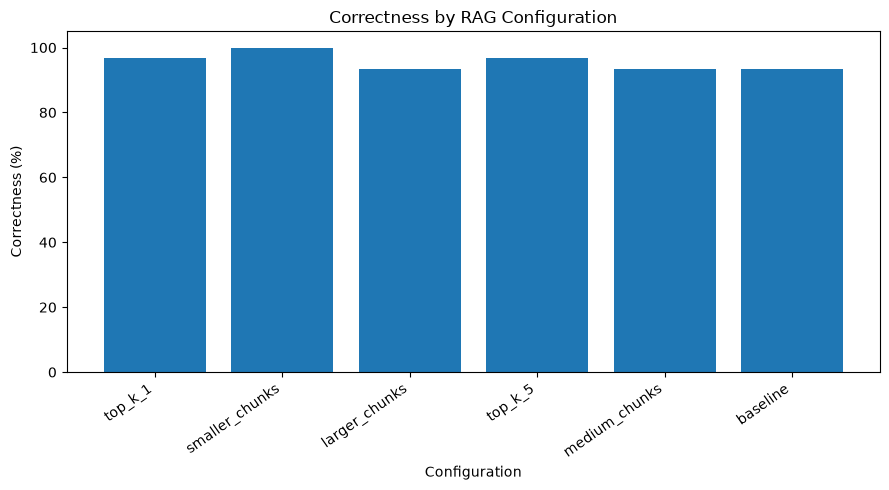

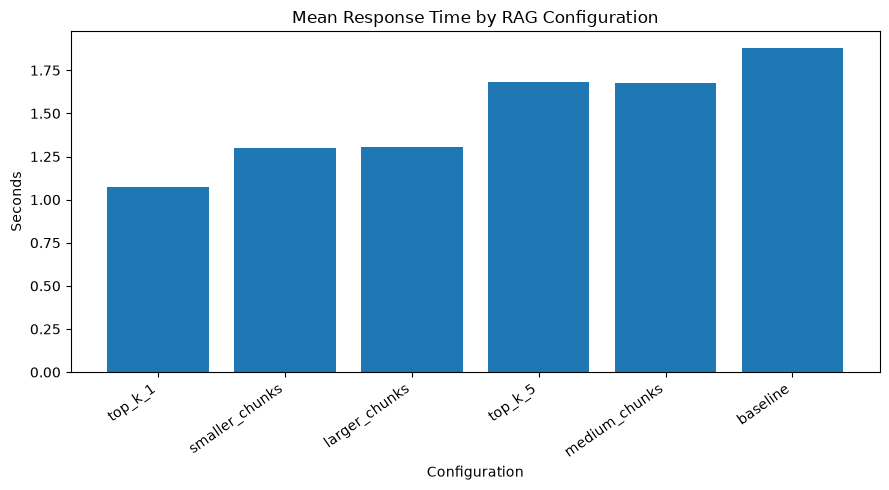

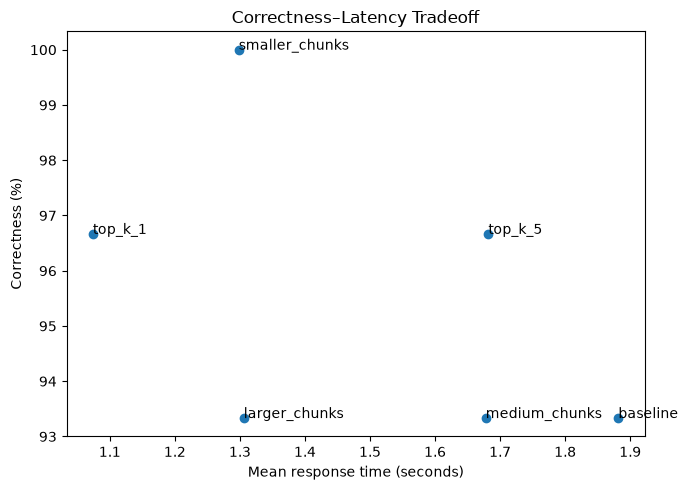

In [10]:
def create_charts(summary: pd.DataFrame) -> None:
    """Create the three report-ready optimization charts."""
    labels = summary.experiment_id
    plt.figure(figsize=(9, 5))
    plt.bar(labels, summary.correctness_percentage)
    plt.title("Correctness by RAG Configuration"); plt.xlabel("Configuration"); plt.ylabel("Correctness (%)")
    plt.xticks(rotation=35, ha="right"); plt.tight_layout()
    plt.savefig(CHARTS_DIR / "correctness_by_configuration.png", dpi=200); plt.show()

    plt.figure(figsize=(9, 5))
    plt.bar(labels, summary.mean_response_time)
    plt.title("Mean Response Time by RAG Configuration"); plt.xlabel("Configuration"); plt.ylabel("Seconds")
    plt.xticks(rotation=35, ha="right"); plt.tight_layout()
    plt.savefig(CHARTS_DIR / "response_time_by_configuration.png", dpi=200); plt.show()

    plt.figure(figsize=(7, 5))
    plt.scatter(summary.mean_response_time, summary.correctness_percentage)
    for row in summary.itertuples():
        plt.annotate(row.experiment_id, (row.mean_response_time, row.correctness_percentage))
    plt.title("Correctness–Latency Tradeoff"); plt.xlabel("Mean response time (seconds)")
    plt.ylabel("Correctness (%)"); plt.tight_layout()
    plt.savefig(CHARTS_DIR / "correctness_latency_tradeoff.png", dpi=200); plt.show()

if scores_ready:
    create_charts(ranked_summary_df)

## 11. Failure Analysis

In [11]:
def failure_analysis(scored: pd.DataFrame, summary: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """Return separate, inspectable tables for required failure categories."""
    frame = scored.copy()
    frame["expected_answerable"] = _boolean_values(frame.expected_answerable)
    baseline = summary.loc[summary.experiment_id.eq("baseline"), "correctness_percentage"].iloc[0]
    context_without_gain = summary[
        (summary.mean_retrieved_context_characters >
         summary.loc[summary.experiment_id.eq("baseline"), "mean_retrieved_context_characters"].iloc[0])
        & (summary.correctness_percentage <= baseline)
    ]
    return {
        "experiments_below_baseline": summary[summary.correctness_change_points < 0],
        "incorrect_questions": frame[pd.to_numeric(frame.correctness) == 0],
        "low_groundedness": frame[pd.to_numeric(frame.groundedness) < 1],
        "retrieval_failures": frame[frame.expected_answerable & (pd.to_numeric(frame.retrieval_hit) == 0)],
        "unanswerable_hallucinations": frame[
            ~frame.expected_answerable & (pd.to_numeric(frame.hallucination_handling) == 0)
        ],
        "slowest_responses": frame.nlargest(min(10, len(frame)), "total_seconds"),
        "more_context_without_accuracy_gain": context_without_gain,
    }

if scores_ready:
    scored_results_df = pd.merge(
        raw_results_df.drop(columns=["correctness", "groundedness", "retrieval_hit", "hallucination_handling", "review_notes"], errors="ignore"),
        manual_review_df[["experiment_id", "question_id", "correctness", "groundedness", "retrieval_hit", "hallucination_handling", "review_notes"]],
        on=["experiment_id", "question_id"], how="inner"
    )
    for title, table in failure_analysis(scored_results_df, ranked_summary_df).items():
        print(f"\n{title.replace('_', ' ').title()}")
        display(table)


Experiments Below Baseline


,experiment_id,question_count,chunk_size,chunk_overlap,top_k,prompt_version,correctness_percentage,fully_correct_percentage,partially_correct_percentage,incorrect_percentage,...,min_similarity,max_similarity,mean_retrieved_context_characters,correctness_change_points,groundedness_change,retrieval_hit_change_points,response_time_change_seconds,response_time_change_percent,archivist_selection_score,simple_rank



Incorrect Questions


,experiment_id,question_id,question,expected_answerable,chunk_size,chunk_overlap,top_k,prompt_version,rag_answer,retrieved_chunk_ids,...,retrieval_seconds,generation_seconds,total_seconds,retrieved_character_count,answer_character_count,correctness,groundedness,retrieval_hit,hallucination_handling,review_notes



Low Groundedness


...

,experiment_id,question_id,question,expected_answerable,chunk_size,chunk_overlap,top_k,prompt_version,rag_answer,retrieved_chunk_ids,...,retrieval_seconds,generation_seconds,total_seconds,retrieved_character_count,answer_character_count,correctness,groundedness,retrieval_hit,hallucination_handling,review_notes



Slowest Responses


,experiment_id,question_id,question,expected_answerable,chunk_size,chunk_overlap,top_k,prompt_version,rag_answer,retrieved_chunk_ids,...,retrieval_seconds,generation_seconds,total_seconds,retrieved_character_count,answer_character_count,correctness,groundedness,retrieval_hit,hallucination_handling,review_notes
0,baseline,1,What is the difference between a datum and data?,True,1000,200,3,strict,The difference between a datum and data is tha...,"[""chunk_0001"", ""chunk_0004"", ""chunk_0005""]",...,0.025318,10.093878,10.119683,2784,224,2.0,1.0,1.0,NaN,AI-assisted draft: fully correct and source-su...
39,medium_chunks,10,What structured data formats are introduced in...,True,800,150,3,strict,The structured data formats introduced in the ...,"[""chunk_0009"", ""chunk_0007"", ""chunk_0008""]",...,0.018793,7.463758,7.482646,2108,443,2.0,1.0,1.0,NaN,AI-assisted draft: fully correct and source-su...
76,top_k_5,2,How does the textbook define a dataset?,True,1000,200,5,strict,A dataset is a collection of observations or d...,"[""chunk_0004"", ""chunk_0000"", ""chunk_0005"", ""ch...",...,0.020989,4.191858,4.212961,4730,366,2.0,1.0,1.0,NaN,AI-assisted draft: fully correct and source-su...
80,top_k_5,6,What is the difference between an item or enti...,True,1000,200,5,strict,The difference between an item or entity and a...,"[""chunk_0004"", ""chunk_0005"", ""chunk_0008"", ""ch...",...,0.020372,2.077003,2.097508,4734,462,1.0,0.5,1.0,NaN,AI-assisted draft: core distinction is correct...
27,larger_chunks,13,Why has data become increasingly important acr...,True,1400,250,3,strict,Data has become increasingly important across ...,"[""chunk_0001"", ""chunk_0000"", ""chunk_0002""]",...,0.019925,1.837127,1.857199,4009,490,2.0,1.0,1.0,NaN,AI-assisted draft: fully correct and source-su...
77,top_k_5,3,What is the difference between structured and ...,True,1000,200,5,strict,Structured data has a fixed schema with consis...,"[""chunk_0005"", ""chunk_0006"", ""chunk_0007"", ""ch...",...,0.021340,1.810885,1.832287,4690,473,2.0,1.0,1.0,NaN,AI-assisted draft: fully correct and source-su...
20,larger_chunks,6,What is the difference between an item or enti...,True,1400,250,3,strict,The difference between an item or entity and a...,"[""chunk_0003"", ""chunk_0002"", ""chunk_0006""]",...,0.018840,1.794304,1.813318,3019,477,1.0,0.5,1.0,NaN,AI-assisted draft: core distinction is correct...
85,top_k_5,11,How does CSV differ from JSON when storing str...,True,1000,200,5,strict,"CSV differs from JSON in that it uses a flat, ...","[""chunk_0007"", ""chunk_0008"", ""chunk_0005"", ""ch...",...,0.020273,1.730842,1.751269,4642,424,2.0,1.0,1.0,NaN,AI-assisted draft: fully correct and source-su...
1,baseline,2,How does the textbook define a dataset?,True,1000,200,3,strict,The textbook defines a dataset as a collection...,"[""chunk_0004"", ""chunk_0000"", ""chunk_0005""]",...,0.030790,1.659923,1.690887,2765,388,2.0,1.0,1.0,NaN,AI-assisted draft: fully correct and source-su...
32,medium_chunks,3,What is the difference between structured and ...,True,800,150,3,strict,"Structured data uses a predefined, consistent ...","[""chunk_0007"", ""chunk_0006"", ""chunk_0008""]",...,0.020175,1.641763,1.662085,2045,380,2.0,1.0,1.0,NaN,AI-assisted draft: fully correct and source-su...



More Context Without Accuracy Gain


,experiment_id,question_count,chunk_size,chunk_overlap,top_k,prompt_version,correctness_percentage,fully_correct_percentage,partially_correct_percentage,incorrect_percentage,...,min_similarity,max_similarity,mean_retrieved_context_characters,correctness_change_points,groundedness_change,retrieval_hit_change_points,response_time_change_seconds,response_time_change_percent,archivist_selection_score,simple_rank
2,larger_chunks,15,1400,250,3,strict,93.333333,86.666667,13.333333,0.0,...,0.581387,0.716598,3678.133333,0.0,-0.033333,0.0,-0.575903,-30.603703,92.962607,5


## 12. Report-Ready Summary

In [12]:
def generate_report_summary(summary_df: pd.DataFrame, baseline_id: str = "baseline") -> str:
    """Generate conservative prose using validated, actual experiment metrics."""
    if summary_df.empty:
        raise ValueError("A validated summary is required.")
    best = summary_df.sort_values(
        ["archivist_selection_score", "correctness_percentage", "average_groundedness", "mean_response_time"],
        ascending=[False, False, False, True],
    ).iloc[0]
    baseline = summary_df[summary_df.experiment_id == baseline_id].iloc[0]
    return (
        f"A total of {len(summary_df)} RAG configurations were evaluated using the same "
        f"{int(best.question_count)}-question test set. The baseline configuration used a "
        f"chunk size of {int(baseline.chunk_size)}, overlap of {int(baseline.chunk_overlap)}, "
        f"and top-k of {int(baseline.top_k)}.\n\n"
        f"By the Archivist project-specific configuration selection score, the highest-performing "
        f"configuration was {best.experiment_id}, using chunk size {int(best.chunk_size)}, overlap "
        f"{int(best.chunk_overlap)}, and top-k {int(best.top_k)}. Its correctness was "
        f"{best.correctness_percentage:.1f}%, average groundedness was {best.average_groundedness:.2f}, "
        f"and retrieval hit rate was {best.retrieval_hit_rate:.1f}%. Relative to baseline, correctness "
        f"changed by {best.correctness_change_points:+.1f} percentage points and mean response time "
        f"changed by {best.response_time_change_seconds:+.2f} seconds "
        f"({best.response_time_change_percent:+.1f}%).\n\n"
        "These quality scores are an AI-assisted draft pending human verification. No statistical significance is claimed. The dataset "
        "and question set were small, so this is an initial optimization study rather than a general "
        "benchmark, and findings may not generalize to other documents or domains."
    )

if scores_ready:
    report_summary = generate_report_summary(ranked_summary_df)
    REPORT_PATH.write_text(report_summary, encoding="utf-8")
    print(report_summary)

A total of 6 RAG configurations were evaluated using the same 15-question test set. The baseline configuration used a chunk size of 1000, overlap of 200, and top-k of 3.

By the Archivist project-specific configuration selection score, the highest-performing configuration was top_k_1, using chunk size 1000, overlap 200, and top-k 1. Its correctness was 96.7%, average groundedness was 0.97, and retrieval hit rate was 100.0%. Relative to baseline, correctness changed by +3.3 percentage points and mean response time changed by -0.81 seconds (-42.9%).

These quality scores are an AI-assisted draft pending human verification. No statistical significance is claimed. The dataset and question set were small, so this is an initial optimization study rather than a general benchmark, and findings may not generalize to other documents or domains.


## 13. Experiment Metadata

In [13]:
def save_experiment_metadata(experiments: list[dict], questions_df: pd.DataFrame) -> None:
    """Save exact fixed settings and environment metadata for reproducibility."""
    source_bytes = SOURCE_PATH.read_bytes()
    metadata = {
        "utc_timestamp": datetime.now(timezone.utc).isoformat(),
        "python_version": sys.version,
        "platform": platform.platform(),
        "chat_model": CHAT_MODEL,
        "embedding_model": EMBEDDING_MODEL,
        "ollama_host": OLLAMA_HOST,
        "temperature": TEMPERATURE,
        "source_file_name": SOURCE_PATH.as_posix(),
        "source_file_sha256": hashlib.sha256(source_bytes).hexdigest(),
        "question_count": int(len(questions_df)),
        "experiment_count": len(experiments),
        "experiments": experiments,
        "notebook_version": NOTEBOOK_VERSION,
    }
    METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

save_experiment_metadata(EXPERIMENTS, questions_df)
print(f"Metadata saved to {METADATA_PATH}")

Metadata saved to results/optimization_metadata.json


## 14. Ethical and Methodological Limitations

- Manual scoring is subject to reviewer bias and should use an instructor-approved rubric.
- Fifteen questions are too few for broad conclusions and encourage overfitting to one textbook section.
- Results may differ for tables, diagrams, scanned PDFs, mathematics, and other document domains.
- Stored user questions and retrieved content can create privacy risks; retain only what is necessary.
- Instructor oversight remains necessary for educational use.
- High groundedness can coexist with incomplete or pedagogically weak explanations.
- Source citations should be preserved so learners and instructors can verify claims.
- Larger retrieved contexts can increase latency without improving answer quality.
- These are descriptive results; the notebook does not claim statistical significance.

### Potential Improvements

Future work could test token-aware or semantic chunking, citation verification, broader
course sections, repeated timing runs, blinded multi-rater scoring, and inter-rater
agreement. A separate relevance classifier, reranker, SHAP, or LIME is intentionally
outside this Track 1 implementation.